# Breast Cancer Wisconsin (Diagnostic) Classification

This notebook loads the Breast Cancer Wisconsin (Diagnostic) dataset, performs exploratory data analysis and preprocessing, trains Logistic Regression and K-Nearest Neighbors classifiers, evaluates them, and compares the results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

# Load the Breast Cancer Wisconsin (Diagnostic) dataset
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame.copy()
df.rename(columns={"target": "diagnosis"}, inplace=True)
df["diagnosis"] = df["diagnosis"].map({0: "malignant", 1: "benign"})

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


### Explanation: Data Loading and Preparation

This cell imports all necessary libraries for machine learning and loads the **Breast Cancer Wisconsin (Diagnostic) dataset** from scikit-learn. 

**What was done:**
- **Libraries imported**: NumPy for numerical operations, Pandas for data manipulation, Matplotlib and Seaborn for visualization, and scikit-learn for machine learning algorithms and evaluation metrics
- **Dataset loaded**: The breast cancer dataset contains 569 samples with 30 features describing tumor characteristics
- **Data mapping**: The target variable was renamed from "target" to "diagnosis" and converted from binary (0/1) to meaningful labels: 0 → "malignant", 1 → "benign"
- **Visualization settings**: Set a clean whitegrid theme for plots

The dataset is now ready for exploratory analysis. The first few rows are displayed to verify correct loading.

Shape: (569, 31)

Column names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'diagnosis']

Class distribution:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64

Missing values per column:
mean radius               0
mean texture              0
mean perimeter            0
mean area                 0
mean smoothness           0
mean compactness          0
mean concavity            0
mean concave points       0
mean symmetry             0
mean fra

C:\Users\Sharon\AppData\Local\Temp\ipykernel_29456\2758623307.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="diagnosis", ax=axes[0], palette="Set2")


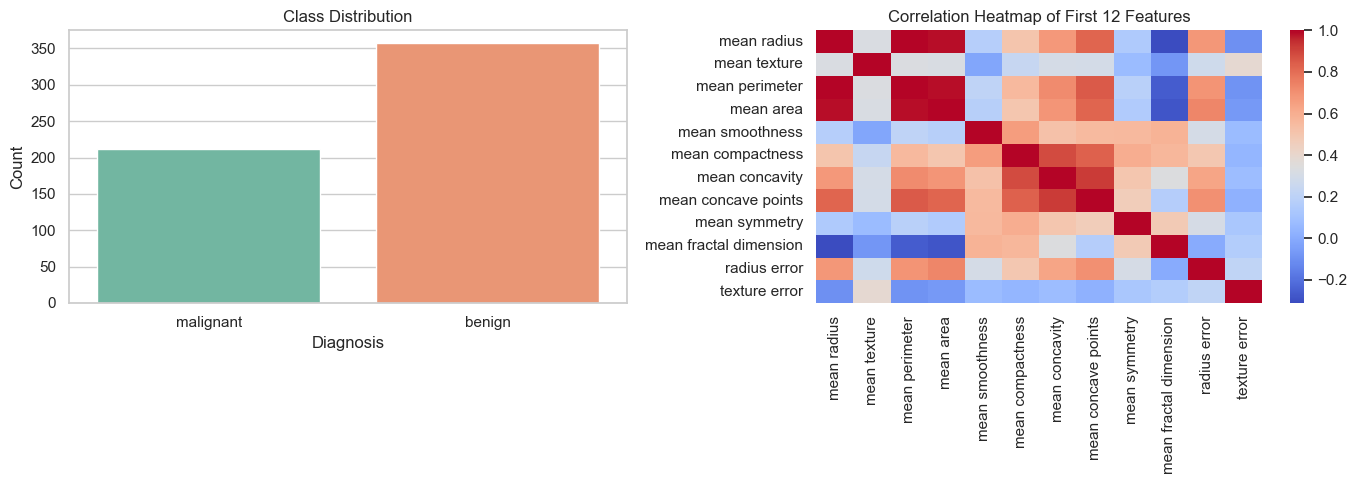

In [2]:
# Exploratory data analysis
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nClass distribution:")
print(df["diagnosis"].value_counts())
print("\nMissing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(10))
print("\nSummary statistics:")
print(df.describe().T.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="diagnosis", ax=axes[0], palette="Set2")
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Count")

sns.heatmap(df.drop(columns=["diagnosis"]).corr().iloc[:12, :12], cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlation Heatmap of First 12 Features")

plt.tight_layout()
plt.show()

### Explanation: Exploratory Data Analysis (EDA)

This cell performs comprehensive exploratory analysis to understand the dataset structure and characteristics.

**What was done:**
- **Dataset shape**: Confirmed the dataset has 569 samples and 31 columns (30 features + 1 diagnosis label)
- **Feature overview**: Displayed all column names to identify available predictors
- **Class distribution**: Checked how many cases are benign vs. malignant (label balance)
- **Missing values**: Verified data completeness—confirmed no missing values
- **Statistical summary**: Computed mean, std, min, max, and quartiles for the first few features to understand data ranges and scales
- **Visualizations**:
  - **Count plot**: Shows the class distribution (benign vs. malignant cases)
  - **Correlation heatmap**: Displays relationships between the first 12 features, helping identify potential multicollinearity and feature importance

This analysis reveals data quality and guides the choice of preprocessing techniques (e.g., scaling) and feature selection strategies.

In [3]:
# Prepare the dataset for classification
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Train Logistic Regression
log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

Training set shape: (455, 30)
Testing set shape: (114, 30)


### Explanation: Data Preparation and Model Training

This cell prepares the data for classification and trains two different machine learning models.

**What was done:**
1. **Feature-target separation**: Separated features (X) from the diagnosis labels (y)
2. **Train-test split**: Divided data into 80% training and 20% testing sets (114 test samples) while maintaining class distribution using stratification
3. **Feature scaling**: Applied StandardScaler to normalize features to mean=0 and std=1, ensuring all features have equal influence on distance-based and gradient-based models
4. **Model 1 - Logistic Regression**:
   - A linear model that outputs probability scores, suitable for binary classification
   - Set max_iter=5000 to ensure convergence
   - Fitted on scaled training data
5. **Model 2 - K-Nearest Neighbors (KNN)**:
   - A non-parametric model that classifies based on 5 nearest neighbors
   - Fitted on scaled training data
6. **Predictions**: Both models generated predictions on the test set for later evaluation

The scaled data ensures fair comparison between models and improves convergence for Logistic Regression.

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.964912   0.959459  0.986111  0.972603
1                  KNN  0.956140   0.946667  0.986111  0.965986

Logistic Regression Classification Report:

              precision    recall  f1-score   support

      benign       0.96      0.99      0.97        72
   malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


KNN Classification Report:

              precision    recall  f1-score   support

      benign       0.95      0.99      0.97        72
   malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



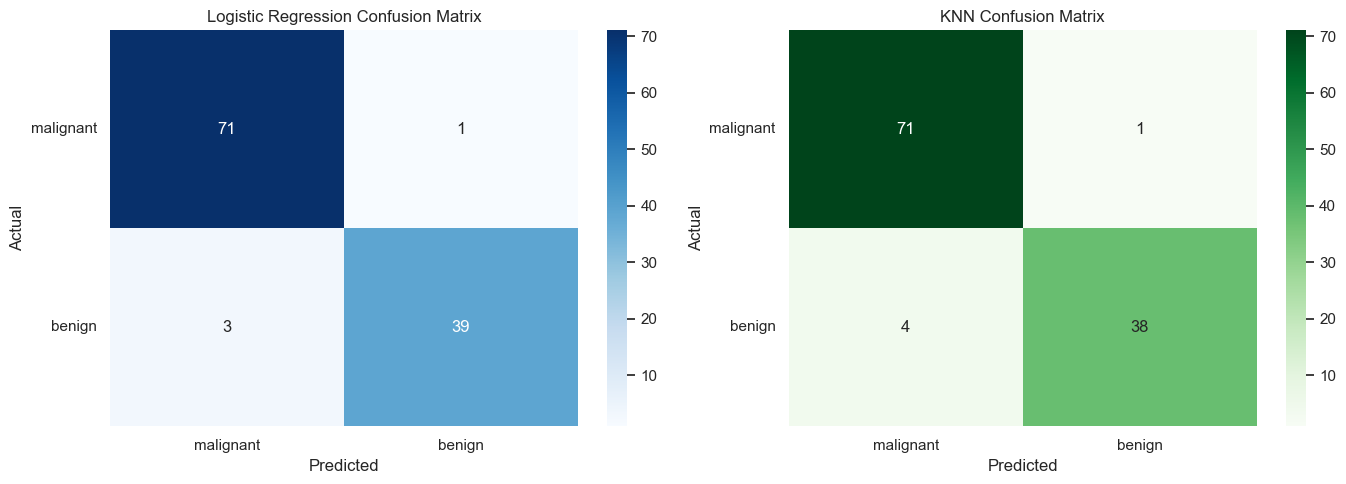

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.964912,0.959459,0.986111,0.972603
1,KNN,0.956140,0.946667,0.986111,0.965986


In [4]:
# Evaluate both classifiers
models = {
    "Logistic Regression": y_pred_lr,
    "KNN": y_pred_knn,
}

results = []
for name, predictions in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, pos_label="benign"),
        "Recall": recall_score(y_test, predictions, pos_label="benign"),
        "F1 Score": f1_score(y_test, predictions, pos_label="benign"),
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
print(results_df)

print("\nLogistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_lr))
print("\nKNN Classification Report:\n")
print(classification_report(y_test, y_pred_knn))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticklabels(["malignant", "benign"])
axes[0].set_yticklabels(["malignant", "benign"], rotation=0)

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("KNN Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_xticklabels(["malignant", "benign"])
axes[1].set_yticklabels(["malignant", "benign"], rotation=0)

plt.tight_layout()
plt.show()

results_df

## Interpretation of Model Evaluation Results

This section evaluates and compares the performance of two classification models—**Logistic Regression** and **KNN**—on the binary classification task of distinguishing between benign and malignant breast cancer diagnoses.

### Key Components:

1. **Performance Metrics Table**
   - **Accuracy**: The overall percentage of correct predictions across both classes
   - **Precision**: Of all cases predicted as "benign," what percentage were actually benign (minimizes false positives)
   - **Recall**: Of all actual "benign" cases in the test set, what percentage were correctly identified (minimizes false negatives)
   - **F1 Score**: The harmonic mean of precision and recall, providing a balanced performance metric

2. **Classification Reports**
   - Provides detailed per-class performance metrics for each model
   - Shows precision, recall, and F1 score broken down by diagnosis class
   - "Support" indicates the number of test samples for each class

3. **Confusion Matrices**
   - Visualizes the distribution of correct and incorrect predictions for each model
   - **Diagonal elements** (True Positives and True Negatives): Correct predictions
   - **Off-diagonal elements** (False Positives and False Negatives): Incorrect predictions
   - Blue heatmap represents Logistic Regression; Green represents KNN

### What This Tells Us:

- **Model Comparison**: The results are sorted by accuracy, allowing easy identification of the better-performing model
- **Trade-offs**: Precision vs. Recall trade-off is visible—high recall means catching most benign cases but may increase false alarms; high precision means fewer false positives but may miss some cases
- **Clinical Relevance**: In medical diagnosis, recall may be more important than precision (it's better to flag and re-examine a borderline case than to miss a malignant tumor)
- **Class Imbalance Detection**: The confusion matrices reveal if one class is harder to predict than the other

### Recommended Next Steps:

- Select the model with better performance for the specific use case
- Consider hyperparameter tuning if both models underperform
- Evaluate on additional validation data to ensure generalization
